# NF $h_{\rm dm}$ fit — single centred Gaussian $f_0$

True $f_0$ = one centred 2-D Gaussian. Reference: an **analytic linear bijection**
$F(u)=a\,u+b$ (4 params, closed form) compared against two normalizing-flow
families — **rigid maps** (a diagonal-affine flow + tiny zero-init couplings, which recover $h$) and **flexible RealNVP** flows (which over-fit and lose $h$).

**One fit per model, many views.** Each model is fitted **once** — jointly in
$(h_{\rm dm},\varphi)$, then $h$ is **profiled** near the minimum for the
uncertainty. Every figure is a view of the single cached result `res`. The NF
parameter sweep spans both
kinds (rigid: diagonal-affine 4p + tiny couplings 8/16/32p; flexible RealNVP: 76/304/1014p). Star count is the `N` knob in the setup
cell (default $20{,}000$; cached per-$N$).

In [ ]:
%matplotlib inline
# reload the experiments package so a kernel started before an edit picks up the
# latest code (avoids stale-module AttributeErrors); restart the kernel if one persists.
import importlib, experiments.common, experiments
importlib.reload(experiments.common); importlib.reload(experiments)
import numpy as np
import experiments as X
from experiments import common as C

# ---- star count (the ONE knob for run cost) ---------------------------------
N = 20_000                 # stars the fit uses (cached per-N as results/<KEY>_N<N>.pkl)
N_DISPLAY = 4 * N          # stars for the sim-data HEATMAP only -- NOT the fit;
                           # a density heatmap needs more stars than the fit does.
z_obs, w_obs = C.make_gaussian_data(N=N, seed_sample=3)
z_disp, w_disp = C.make_gaussian_data(N=N_DISPLAY, seed_sample=3)
true_pdf_z = lambda g: C.gauss_pdf(g, 0.0, C.Z0_SIGMA)
true_pdf_w = lambda g: C.gauss_pdf(g, 0.0, C.W0_SIGMA)

# ---- 2D heatmap display window (DYNAMICAL: edit Q_CLIP to zoom) --------------
# The corners of the phase-space heatmaps carry little information; concentrate on
# the central structure.  Q_CLIP is the percentile that sets the window from the
# data itself -- LOWER Q_CLIP = TIGHTER zoom on the centre.  ZLIM/WLIM are passed
# to every 2D plot below.
Q_CLIP = 97.0
zc = np.percentile(np.abs(z_obs - np.median(z_obs)), Q_CLIP)
wc = np.percentile(np.abs(w_obs - np.median(w_obs)), Q_CLIP)
ZLIM = (-zc, zc)
WLIM = (np.median(w_obs) - wc, np.median(w_obs) + wc)
print(f"N(fit)={N}  N(display)={N_DISPLAY}   ZLIM={ZLIM[0]:.0f}..{ZLIM[1]:.0f} pc   WLIM={WLIM[0]:.0f}..{WLIM[1]:.0f} km/s")

# THE single fit: each model fitted once (joint h+phi -> profile h), cached to
# results/PG_N{N}.pkl.  EVERY plot below reads THIS -- nothing re-fits.
res = X.run("PG", cfg={"N": N})


: 

## The simulated data

The snapshot the whole notebook fits, as phase-space heatmaps: **rows** = the two
times ($t=0$ back-integrated, $t=400$ Myr observed), **columns** = the density
$f(z,w)$ and its *residual* (density minus its azimuthal average, exposing the
phase-space **spiral** that anharmonic phase mixing winds in by $t=400$ Myr). The
analytic joint $f_0$ is overlaid (white contours on density, black on residual).
Heatmaps zoomed to `ZLIM`/`WLIM`. This view uses the denser `N_DISPLAY` draw (a
heatmap needs more stars than the fit); it does not affect the fit.

In [ ]:
C.plot_simulated_data(z_disp, w_disp, true_pdf_z, true_pdf_w,
                     zlim=ZLIM, wlim=WLIM,
                     title="Simulated snapshot: $t=0$ and the $t=400$ Myr phase-space spiral");


: 

## True vs fitted $f_0$ — 1-D marginals per fit, at $t=0$ and $t=400$ Myr

True $f_0$ (black dashed) vs each fitted $f_0$ (red), in $z$ and $w$ separately,
one row per fit; columns 1–2 are $t=0$ ($z_0,w_0$), columns 3–4 the same fits
**evolved to $t=400$ Myr**. Summed from the very same best-fit density used for the
2-D panels — every view comes from the one fit `res` (each model fitted once:
joint $(h,\varphi)$, then $h$ profiled near the minimum).

This panel shows **every** fit in the parameter sweep — one row each, both families and every flow (plus the analytic reference where present). The heavier
2-D density panel below shows only a representative subset, for readability.

In [ ]:
# 1-D marginals of EVERY model's single best-fit f0 (the whole ladder), from `res`
C.plot_all_models_distributions(res);


: 

## The fitted phase-space function of each fit — true vs fitted $f_0$ with the data

The same featured fits as 2-D **functions**: one row per model, two columns ($t=0$
and $t=400$ Myr). Each panel overlays **true $f_0$** (black solid contours),
**fitted $f_0$** (red dashed, same levels) and the **data** underneath, zoomed to
`ZLIM`/`WLIM`. Where the fitted $h$ is wrong the red and black spirals part.

In [ ]:
# 2-D true (black) vs fitted (red) f0 with data, per featured fit (from `res`)
C.plot_phase_space_density(res, zlim=ZLIM, wlim=WLIM);


: 

In [ ]:
# Key: black solid = TRUE f_0, red dashed = FITTED f_0, grey points = data.
C.plot_phase_space_density_legend();


: 

## Results for $h_{\rm dm}$ and the profile likelihood

The uncertainty side of the single fit, across both bijection families (rigid maps + flexible RealNVP): at each fixed $h$ the
bijection params $\varphi$ are re-optimised, giving
$\mathrm{NLL}_p(h)=\min_\varphi\mathrm{NLL}(h,\varphi)$. Best-fit $h_{\rm dm}$ =
minimum; error bar = the $\Delta$NLL$=0.5$ ($1\sigma$) half-width. Panels: profile
$\Delta$NLL$(h)$ per NF kind (one curve per #params), and **well depth vs
#parameters** — the direct "how the fit changes as the flow grows" view.

In [ ]:
C.plot_profiles(res,
                title="profile likelihood by NF kind & #parameters");


: 

## The fit residual winds into a phase-space spiral at $t=400$ Myr

The 2-D residual (flow $-$ true) of one selected fit. **Top ($t=0$):** smooth
low-order blob. **Bottom ($t=400$ Myr):** differential phase mixing **winds it
into a spiral**. Selects an already-fitted model from `res` (no re-fit); here it shows a flexible RealNVP fit (`kind="flex"`), whose wrong-$h$ over-fit makes the residual spiral vivid. Zoomed to `ZLIM`/`WLIM`.

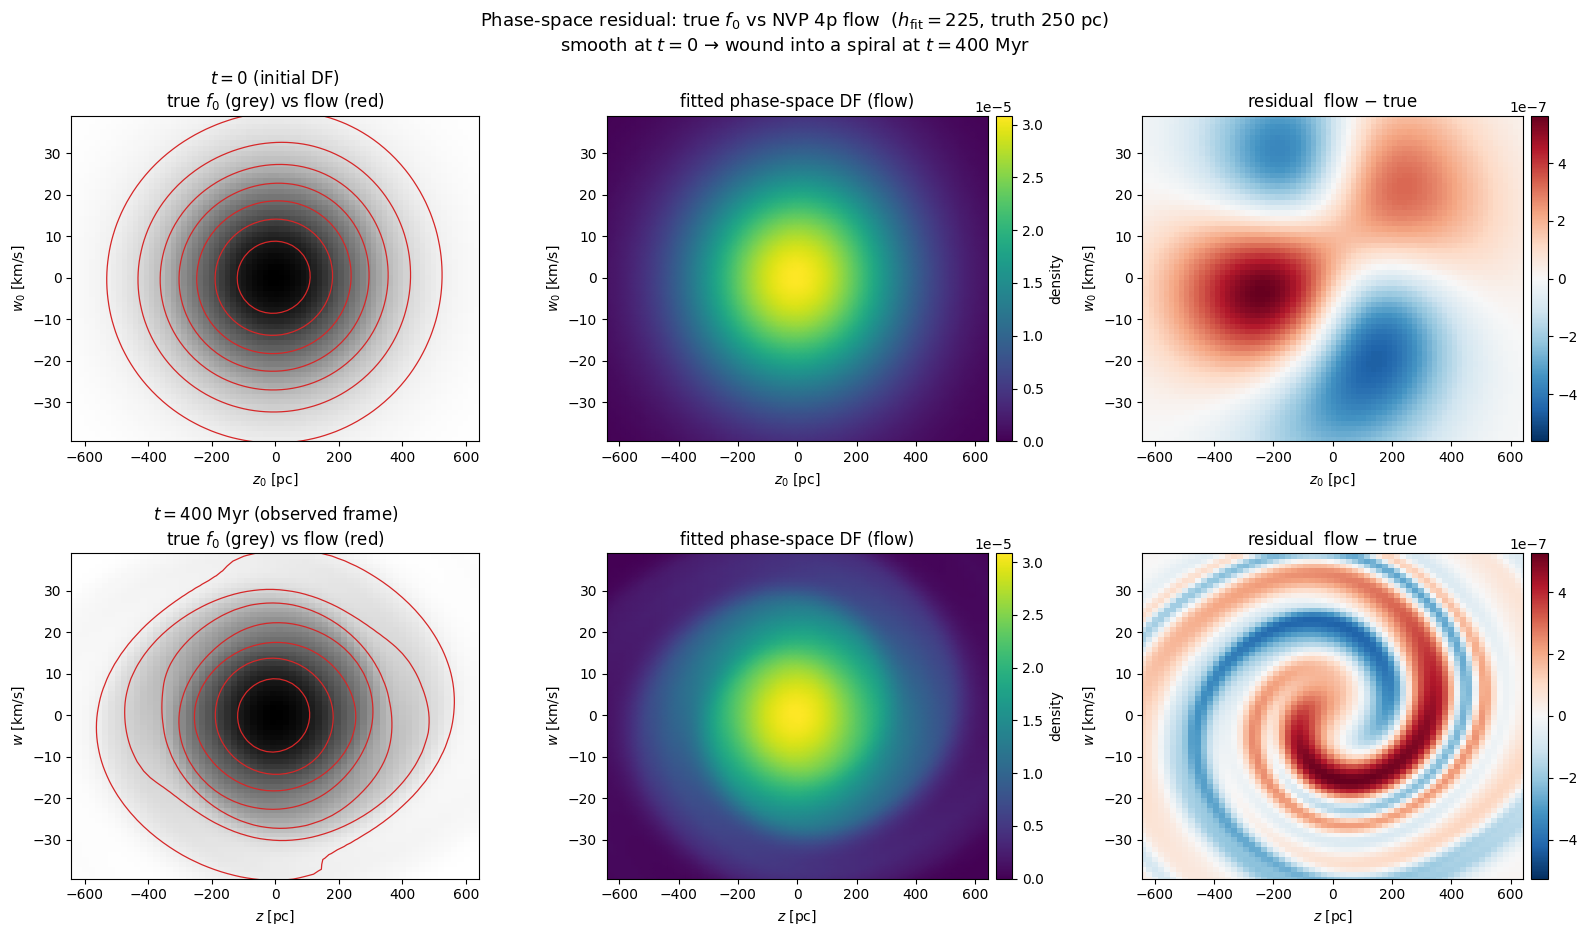

In [7]:
C.plot_spiral_residual(res, kind="flex", size=0, zlim=ZLIM, wlim=WLIM);


## Initial-guess analysis — does fitted $h$ track its start?

Fit each flow from several starting guesses $h_{\rm init}$ and see where $h$ lands.
A rigid / well-fitting model returns to the truth regardless of start; a
flexible-but-underconverged one appears to follow its guess — a symptom of
under-convergence.

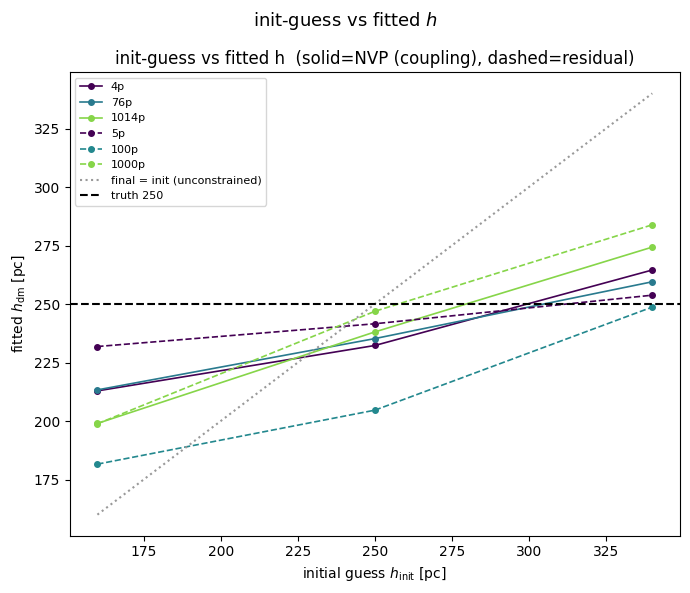

In [8]:
C.plot_init_guess_map(res,
                     title="init-guess vs fitted $h$");


## Joint fit of $(h_{\rm dm},\varphi)$, then the profile likelihood **around that minimum**

The fit done properly — **not** a scan over a fixed $200$–$300$ grid:

1. **joint fit** — $h_{\rm dm}$ and every flow parameter $\varphi$ descend *together*
   (Adam on both), from several starting guesses $\Rightarrow$ the joint MLE $\hat h$;
2. **profile** — the grid is then placed **around $\hat h$** ($\hat h\pm60$ pc, dense near
   the centre) and at each *fixed* $h$ **all** the other parameters are re-optimised,
   warm-started outward from $\hat\varphi$: $\mathrm{NLL}_p(h)=\min_\varphi\mathrm{NLL}(h,\varphi)$;
3. **uncertainty** — $1\sigma$ = half-width of that curve at $\Delta\mathrm{NLL}=0.5$ (Wilks).

Each re-fit is Adam **plus an LBFGS polish**: with $N=20\,000$ stars a residual optimisation
error of $10^{-5}$ nats/star is already $0.2$ nats — the size of the $\Delta=0.5$ threshold
itself, so without the polish the "uncertainty curve" would be optimiser noise.

**Result for the centred-Gaussian $f_0$** (true $h=250$ pc): the **minimal** model wins.
The 4-parameter diagonal-affine map gives $h_{\rm dm}=248.2\pm5.8$ pc and its profile lies
exactly on the closed-form analytic curve (dotted); the joint fit returns $251.6/252.1/251.3$
from $h_{\rm init}=200/250/320$ — no memory of the start. Adding capacity only hurts:
$16$p widens to $\pm19.7$, and the $272$p flexible flow over-fits to $273.5\pm2.4$ pc —
tight *and* wrong, $\sim10\sigma$ off. Panel 4 shows why: every model reproduces this simple
$f_0$, so the extra parameters buy nothing and spend themselves on the phase-mixed noise.
(The two-width notebook is the opposite case — there $272$ parameters are what it takes.)

Computed once by `experiments/joint_profile_fit.py` (`python3 experiments/joint_profile_fit.py pg`,
cached in `results/JP_pg.pkl` / `JP_2w.pkl` / `JP_figure.pkl`); the cell below only draws it.


In [ ]:
# Joint (h_dm, flow) fit -> profile around the joint minimum.  Left column = this
# notebook's Gaussian f0 (best at the MINIMAL number of parameters), right column =
# the two-width f0 (best at 272).  Pure drawing: nothing re-fits.
C.plot_joint_profile();
C.joint_profile_table()
